In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
import shap
from sklearn.inspection import permutation_importance
from statsmodels.stats.multitest import multipletests
pd.set_option('display.max_columns', None)

In [2]:
enroll = pd.read_excel("enroll.xlsx", header=1)
enroll.head()

,subjid,studyid,seq,visit,visdy,visstat,age,capscore,hdiss_stage_imp,hdiss_stage0_prob,hdiss_stage1_prob,hdiss_stage2_prob,hdiss_stage3_prob,hdcat,hxalcab,hxtobab,hxtobcpd,hxtobyos,hxpacky,hxdrugab,hxmar,hxmarfrq,hxher,hxherfrq,hxcoc,hxcocfrq,hxclb,hxclbfrq,hxamp,hxampfrq,hxrit,hxritfrq,hxhal,hxhalfrq,hxinh,hxinhfrq,hxopi,hxopifrq,hxpak,hxpakfrq,hxbar,hxbarfrq,hxtrq,hxtrqfrq,bmi_imp,alcab,alcunits,tobab,tobcpd,tobyos,packy,cafab,cafpd,drugab,mar,marfrq,her,herfrq,coc,cocfrq,clb,clbfrq,amp,ampfrq,rit,ritfrq,hal,halfrq,inh,inhfrq,opi,opifrq,pak,pakfrq,bar,barfrq,trq,trqfrq,updsc,res,isced,jobclas,jobpaid,rdcwk,rdcwkd,rdcwkhw,emplnrsn,emplnrd,ssdb,rtrnwk,rtrddur,updmed,updmh,updhdh,updfh,motscore,miscore,ocularh,ocularv,sacinith,sacinitv,sacvelh,sacvelv,dysarth,tongue,fingtapr,fingtapl,prosupr,prosupl,luria,rigarmr,rigarml,brady,dysttrnk,dystrue,dystlue,dystrle,dystlle,chorface,chorbol,chortrnk,chorrue,chorlue,chorrle,chorlle,gait,tandem,retropls,diagconf,tfcscore,occupatn,finances,chores,adl,carelevl,fascore,fiscore,emplusl,emplany,volunt,fafinan,grocery,cash,supchild,drive,housewrk,laundry,prepmeal,telephon,ownmeds,feedself,dress,bathe,pubtrans,walknbr,walkfall,walkhelp,comb,trnchair,bed,toilet,carehome,indepscl,gen1,gen2,gen3,gen4,gen5,gen6,sdmt,sdmt1,sdmt2,sdmtnd,verfct,verfctd,verfct5,verfct6,verfct7,verfctnd,scnt,scnt1,scnt2,scnt3,scntnd,swrt,swrt1,swrt2,swrt3,swrtnd,sit,sit1,sit2,sit3,trl,trla1,trla2,trla3,trlb1,trlb2,trlb3,verflt,verflt05,verflt06,verflt07,mmsetotal,tug,tug1,scst,scst1,depscore,irascore,psyscore,aptscore,exfscore,pbas1sv,pbas1fr,pbas1wo,pbas2sv,pbas2fr,pbas2wo,pbas3sv,pbas3fr,pbas3wo,pbas4sv,pbas4fr,pbas4wo,pbas5sv,pbas5fr,pbas5wo,pbas6sv,pbas6fr,pbas6wo,pbas7sv,pbas7fr,pbas7wo,pbas8sv,pbas8fr,pbas8wo,pbas9sv,pbas9fr,pbas9wo,pbas10sv,pbas10sm__1,pbas10sm__2,pbas10sm__3,pbas10sm__4,pbas10sm__5,pbas10fr,pbas10wo,pbas11sv,pbas11fr,pbas11wo,pbainfo,pbahshd,scoring,pf,rp,bp,gh,vt,sf,re,mh,pcs,mcs,anxscore,hads_depscore,irrscore,outscore,inwscore,wpaiscr1,wpaiscr2,wpaiscr3,wpaiscr4,sid1,sid2,sid3,sid4,sid5,int1,int2,int3,int4,int5,int6,sbh1,sbh1n,sbh2,sbh3,sbh3n,sbh4,sbh4n,sbh5,sbh6,sbh7,attmpt1dy,attmpt11,attmpt12,attmpt2dy,attmpt21,attmpt22,attmpt3dy,attmpt31,attmpt32,mvsrc,mvrsn,crlvl,dpdy
0,R000024542,ENR,1,Baseline,0,completed,48,103.5,3.0,0.0,0.0,0.0,1.0,3.0,0.0,0.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,19.8,1.0,0.0,0.0,NaN,NaN,NaN,1.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,4.0,1.0,1.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,28.0,28.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,2.0,1.0,2.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,1.0,2.0,2.0,2.0,1.0,1.0,1.0,1.0,1.0,4.0,11.0,2.0,2.0,2.0,3.0,2.0,24.0,24.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,95.0,1.0,NaN,NaN,NaN,NaN,NaN,1.0,21.0,1.0,NaN,1.0,1.0,11.0,0.0,1.0,NaN,1.0,43.0,0.0,0.0,NaN,1.0,45.0,0.0,3.0,NaN,1.0,21.0,0.0,2.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,1.0,4.0,0.0,0.0,25.0,NaN,NaN,NaN,NaN,8.0,10.0,0.0,1.0,6.0,0.0,0.0,9997.0,0.0,0.0,9997.0,2.0,4.0,9997.0,3.0,2.0,9997.0,2.0,2.0,9997.0,1.0,1.0,9997.0,2.0,3.0,9997.0,0.0,0.0,9997.0,0.0,0.0,9997.0,0.0,NaN,NaN,NaN,NaN,NaN,0.0,9997.0,0.0,0.0,9997.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,R000024542,ENR,2,Follow Up,371,completed,49,105.7,3.0,0.0,0.0,0.0,1.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,19.6,1.0,0.0,0.0,NaN,NaN,NaN,1.0,1.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,0.0,0.0,32.0,32.0,1.0,1.0,1.0,2.0,1.0,2.0,0.0,2.0,2.0,2.0,2.0,2

In [3]:
snps = pd.read_csv("all_SNP.csv")
snps.head()

,FID,IID,PAT,MAT,SEX,PHENOTYPE,19_45409113_C_T_T,19_45409167_C_G_C,19_45409283_C_A_A,19_45409579_C_T_T,19_45409988_C_T_T,19_45410002_G_A_A,19_45410273_G_A_A,19_45410444_G_A_A,19_45410548_A_G_G,19_45410911_T_G_G,19_45411110_T_C_C,19_45411722_G_A_A,19_45411941_T_C_C,19_45412040_C_T_T,19_45412079_C_T_T
0,R740999249,R740999249_D01,0,0,2,-9,0,0,0,0,0,1,0,1,0,0,0,0,1,0,0
1,R847813716,R847813716_B02,0,0,2,-9,0,0,0,0,0,2,0,0,0,0,0,0,2,0,0
2,R353317837,R353317837_E02,0,0,1,-9,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0
3,R151690013,R151690013_C12,0,0,1,-9,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0
4,R940785560,R940785560_A01,0,0,2,-9,0,0,0,0,0,1,0,0,0,0,0,0,1,0,1


In [4]:
profile = pd.read_excel("1. profile.xlsx")
profile.head()

,subjid,region,sex,race,handed,hxsid,dssage,dsplace,dsend,caghigh,caglow,momhd,momagesx,dadhd,dadagesx,xfhx,ccmtr,ccmtrage,sxsubj,sxsubjm,sxs_m,sxs_c,sxs_p,sxs_o,sxfam,sxfamm,sxf_m,sxf_c,sxf_p,sxf_o,hddiagn,sxest,sxrater,sxestcfd,sxreas,sxgs,sxgsdy,sxraterm,sxr_m,sxr_c,sxr_p,sxr_o,ccdep,ccdepage,ccirb,ccirbage,ccvab,ccvabage,ccapt,ccaptage,ccpob,ccpobage,ccpsy,ccpsyage,ccpsyfh,cccog,cccogage,xgwas,xbsp,xpheno,xmorpho,ximage
0,R000024542,Northern America,m,1,1,0.0,NaN,NaN,NaN,44,19,1.0,50.0,0.0,NaN,1,1.0,42.0,42.0,1.0,NaN,NaN,NaN,NaN,42.0,1.0,NaN,NaN,NaN,NaN,47.0,1.0,42.0,1.0,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,0.0,NaN,1.0,46.0,0.0,NaN,0.0,NaN,1.0,46.0,0.0,NaN,NaN,0.0,NaN,1,0,0,0,0
1,R000033502,Latin America,m,3,1,0.0,NaN,NaN,NaN,26,18,0.0,NaN,1.0,55.0,1,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,1.0,15.0,1.0,15.0,0.0,NaN,0.0,NaN,0.0,NaN,NaN,0.0,NaN,0,0,0,0,0
2,R00010372X,Northern America,m,1,1,0.0,NaN,NaN,NaN,41,22,0.0,NaN,9999.0,NaN,1,1.0,61.0,60.0,6.0,1.0,NaN,1.0,NaN,60.0,6.0,1.0,NaN,1.0,NaN,64.0,1.0,60.0,2.0,NaN,NaN,NaN,6.0,1.0,NaN,1.0,NaN,1.0,59.0,1.0,59.0,1.0,59.0,1.0,72.0,0.0,NaN,0.0,NaN,NaN,1.0,63.0,1,0,0,0,0
3,R000141976,Northern America,f,1,1,1.0,NaN,NaN,NaN,42,18,0.0,NaN,1.0,45.0,1,1.0,46.0,50.0,2.0,NaN,NaN,NaN,NaN,50.0,3.0,NaN,NaN,NaN,NaN,51.0,1.0,50.0,2.0,NaN,NaN,NaN,6.0,1.0,1.0,1.0,1.0,1.0,18.0,1.0,18.0,1.0,18.0,1.0,30.0,1.0,51.0,0.0,NaN,NaN,1.0,51.0,0,0,0,0,0
4,R000147438,Europe,m,1,3,0.0,NaN,NaN,NaN,41,23,9999.0,NaN,9999.0,NaN,1,1.0,76.0,76.0,1.0,NaN,NaN,NaN,NaN,77.0,1.0,NaN,NaN,NaN,NaN,81.0,1.0,76.0,1.0,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,1.0,33.0,0.0,NaN,0.0,NaN,1.0,80.0,1.0,81.0,0.0,NaN,NaN,0.0,NaN,0,0,0,0,0


In [5]:
profile_new = profile.rename(columns={'subjid': 'FID'})
enroll_new = enroll.rename(columns={'subjid': 'FID'})

In [6]:
df_temp = pd.merge(enroll_new, snps,on='FID')
df_snps = pd.merge(df_temp, profile_new,on='FID')
df_snps.head()

,FID,studyid,seq,visit,visdy,visstat,age,capscore,hdiss_stage_imp,hdiss_stage0_prob,hdiss_stage1_prob,hdiss_stage2_prob,hdiss_stage3_prob,hdcat,hxalcab,hxtobab,hxtobcpd,hxtobyos,hxpacky,hxdrugab,hxmar,hxmarfrq,hxher,hxherfrq,hxcoc,hxcocfrq,hxclb,hxclbfrq,hxamp,hxampfrq,hxrit,hxritfrq,hxhal,hxhalfrq,hxinh,hxinhfrq,hxopi,hxopifrq,hxpak,hxpakfrq,hxbar,hxbarfrq,hxtrq,hxtrqfrq,bmi_imp,alcab,alcunits,tobab,tobcpd,tobyos,packy,cafab,cafpd,drugab,mar,marfrq,her,herfrq,coc,cocfrq,clb,clbfrq,amp,ampfrq,rit,ritfrq,hal,halfrq,inh,inhfrq,opi,opifrq,pak,pakfrq,bar,barfrq,trq,trqfrq,updsc,res,isced,jobclas,jobpaid,rdcwk,rdcwkd,rdcwkhw,emplnrsn,emplnrd,ssdb,rtrnwk,rtrddur,updmed,updmh,updhdh,updfh,motscore,miscore,ocularh,ocularv,sacinith,sacinitv,sacvelh,sacvelv,dysarth,tongue,fingtapr,fingtapl,prosupr,prosupl,luria,rigarmr,rigarml,brady,dysttrnk,dystrue,dystlue,dystrle,dystlle,chorface,chorbol,chortrnk,chorrue,chorlue,chorrle,chorlle,gait,tandem,retropls,diagconf,tfcscore,occupatn,finances,chores,adl,carelevl,fascore,fiscore,emplusl,emplany,volunt,fafinan,grocery,cash,supchild,drive,housewrk,laundry,prepmeal,telephon,ownmeds,feedself,dress,bathe,pubtrans,walknbr,walkfall,walkhelp,comb,trnchair,bed,toilet,carehome,indepscl,gen1,gen2,gen3,gen4,gen5,gen6,sdmt,sdmt1,sdmt2,sdmtnd,verfct,verfctd,verfct5,verfct6,verfct7,verfctnd,scnt,scnt1,scnt2,scnt3,scntnd,swrt,swrt1,swrt2,swrt3,swrtnd,sit,sit1,sit2,sit3,trl,trla1,trla2,trla3,trlb1,trlb2,trlb3,verflt,verflt05,verflt06,verflt07,mmsetotal,tug,tug1,scst,scst1,depscore,irascore,psyscore,aptscore,exfscore,pbas1sv,pbas1fr,pbas1wo,pbas2sv,pbas2fr,pbas2wo,pbas3sv,pbas3fr,pbas3wo,pbas4sv,pbas4fr,pbas4wo,pbas5sv,pbas5fr,pbas5wo,pbas6sv,pbas6fr,pbas6wo,pbas7sv,pbas7fr,pbas7wo,pbas8sv,pbas8fr,pbas8wo,pbas9sv,pbas9fr,pbas9wo,pbas10sv,pbas10sm__1,pbas10sm__2,pbas10sm__3,pbas10sm__4,pbas10sm__5,pbas10fr,pbas10wo,pbas11sv,pbas11fr,pbas11wo,pbainfo,pbahshd,scoring,pf,rp,bp,gh,vt,sf,re,mh,pcs,mcs,anxscore,hads_depscore,irrscore,outscore,inwscore,wpaiscr1,wpaiscr2,wpaiscr3,wpaiscr4,sid1,sid2,sid3,sid4,sid5,int1,int2,int3,int4,int5,int6,sbh1,sbh1n,sbh2,sbh3,sbh3n,sbh4,sbh4n,sbh5,sbh6,sbh7,attmpt1dy,attmpt11,attmpt12,attmpt2dy,attmpt21,attmpt22,attmpt3dy,attmpt31,attmpt32,mvsrc,mvrsn,crlvl,dpdy,IID,PAT,MAT,SEX,PHENOTYPE,19_45409113_C_T_T,19_45409167_C_G_C,19_45409283_C_A_A,19_45409579_C_T_T,19_45409988_C_T_T,19_45410002_G_A_A,19_45410273_G_A_A,19_45410444_G_A_A,19_45410548_A_G_G,19_45410911_T_G_G,19_45411110_T_C_C,19_45411722_G_A_A,19_45411941_T_C_C,19_45412040_C_T_T,19_45412079_C_T_T,region,sex,race,handed,hxsid,dssage,dsplace,dsend,caghigh,caglow,momhd,momagesx,dadhd,dadagesx,xfhx,ccmtr,ccmtrage,sxsubj,sxsubjm,sxs_m,sxs_c,sxs_p,sxs_o,sxfam,sxfamm,sxf_m,sxf_c,sxf_p,sxf_o,hddiagn,sxest,sxrater,sxestcfd,sxreas,sxgs,sxgsdy,sxraterm,sxr_m,sxr_c,sxr_p,sxr_o,ccdep,ccdepage,ccirb,ccirbage,ccvab,ccvabage,ccapt,ccaptage,ccpob,ccpobage,ccpsy,ccpsyage,ccpsyfh,cccog,cccogage,xgwas,xbsp,xpheno,xmorpho,ximage
0,R000024542,ENR,1,Baseline,0,completed,48,103.5,3.0,0.0,0.0,0.0,1.0,3.0,0.0,0.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,19.8,1.0,0.0,0.0,NaN,NaN,NaN,1.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,4.0,1.0,1.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,28.0,28.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,2.0,1.0,2.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,1.0,2.0,2.0,2.0,1.0,1.0,1.0,1.0,1.0,4.0,11.0,2.0,2.0,2.0,3.0,2.0,24.0,24.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,95.0,1.0,NaN,NaN,NaN,NaN,NaN,1.0,21.0,1.0,NaN,1.0,1.0,11.0,0.0,1.0,NaN,1.0,43.0,0.0,0.0,NaN,1.0,45.0,0.0,3.0,NaN,1.0,21.0,0.0,2.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,1.0,4.0,0.0,0.0,25.0,NaN,NaN,NaN,NaN,8.0,10.0,0.0,1.0,6.0,0.0,0.0,9997.0,0.0,0.0,9997.0,2.0,4.0,9997.0,3.0,2.0,9997.0,2.0,2.0,9997.0,1.0,1.0,9997.0,2.0,3.0,9997.0,0.0,0.0,9997.0,0.0,0.0,9997.0,0.0,NaN,NaN,NaN,N

In [7]:
df_analisis = df_snps[['FID','age','sex','isced','motscore','depscore','irascore','psyscore','aptscore','exfscore','caghigh','caglow','ccdepage', 'ccirbage', 'ccvabage', 'ccaptage', 
    'ccpobage', 'ccpsyage', 'cccogage','sxsubjm','race','region','hdiss_stage_imp','mmsetotal','sdmt1','verfct5','scnt1','swrt1',
    "19_45409113_C_T_T",
    "19_45409167_C_G_C",
    "19_45409283_C_A_A",
    "19_45409579_C_T_T",
    "19_45409988_C_T_T",
    "19_45410002_G_A_A",
    "19_45410273_G_A_A",
    "19_45410444_G_A_A",
    "19_45410548_A_G_G",
    "19_45410911_T_G_G",
    "19_45411110_T_C_C",
    "19_45411722_G_A_A",
    "19_45411941_T_C_C",
    "19_45412040_C_T_T",
    "19_45412079_C_T_T"]]


df_analisis.head()

,FID,age,sex,isced,motscore,depscore,irascore,psyscore,aptscore,exfscore,caghigh,caglow,ccdepage,ccirbage,ccvabage,ccaptage,ccpobage,ccpsyage,cccogage,sxsubjm,race,region,hdiss_stage_imp,mmsetotal,sdmt1,verfct5,scnt1,swrt1,19_45409113_C_T_T,19_45409167_C_G_C,19_45409283_C_A_A,19_45409579_C_T_T,19_45409988_C_T_T,19_45410002_G_A_A,19_45410273_G_A_A,19_45410444_G_A_A,19_45410548_A_G_G,19_45410911_T_G_G,19_45411110_T_C_C,19_45411722_G_A_A,19_45411941_T_C_C,19_45412040_C_T_T,19_45412079_C_T_T
0,R000024542,48,m,4.0,28.0,8.0,10.0,0.0,1.0,6.0,44,19,NaN,46.0,NaN,NaN,46.0,NaN,NaN,1.0,1,Northern America,3.0,25.0,21.0,11.0,43.0,45.0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1
1,R000024542,49,m,4.0,32.0,4.0,0.0,0.0,3.0,8.0,44,19,NaN,46.0,NaN,NaN,46.0,NaN,NaN,1.0,1,Northern America,3.0,24.0,12.0,9.0,31.0,32.0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1
2,R000024542,50,m,4.0,45.0,3.0,0.0,0.0,2.0,2.0,44,19,NaN,46.0,NaN,NaN,46.0,NaN,NaN,1.0,1,Northern America,3.0,24.0,9.0,6.0,53.0,26.0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1
3,R000024542,51,m,4.0,45.0,0.0,0.0,0.0,9.0,2.0,44,19,NaN,46.0,NaN,NaN,46.0,NaN,NaN,1.0,1,Northern America,3.0,18.0,12.0,6.0,16.0,23.0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1
4,R000024542,52,m,4.0,47.0,0.0,0.0,0.0,0.0,6.0,44,19,NaN,46.0,NaN,NaN,46.0,NaN,NaN,1.0,1,Northern America,3.0,19.0,1.0,6.0,9.0,11.0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1


In [8]:
cols_ohe = [
    'region', 'sex', 'race',
    'sxsubjm'
]

df_analisis = df_analisis.replace('>70', 71)
df_analisis = df_analisis.replace('>28', 29)
cols_numericas = df_analisis.select_dtypes(include=['number']).columns
df_analisis[cols_numericas] = df_analisis[cols_numericas].where(df_analisis[cols_numericas] < 150)

df_analisis_ohe = pd.get_dummies(df_analisis, columns= cols_ohe, drop_first=False)
df_analisis_ohe.columns

C:\Users\danil\AppData\Local\Temp\ipykernel_1228\2712455365.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_analisis = df_analisis.replace('>70', 71)
C:\Users\danil\AppData\Local\Temp\ipykernel_1228\2712455365.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_analisis = df_analisis.replace('>28', 29)


Index(['FID', 'age', 'isced', 'motscore', 'depscore', 'irascore', 'psyscore',
       'aptscore', 'exfscore', 'caghigh', 'caglow', 'ccdepage', 'ccirbage',
       'ccvabage', 'ccaptage', 'ccpobage', 'ccpsyage', 'cccogage',
       'hdiss_stage_imp', 'mmsetotal', 'sdmt1', 'verfct5', 'scnt1', 'swrt1',
       '19_45409113_C_T_T', '19_45409167_C_G_C', '19_45409283_C_A_A',
       '19_45409579_C_T_T', '19_45409988_C_T_T', '19_45410002_G_A_A',
       '19_45410273_G_A_A', '19_45410444_G_A_A', '19_45410548_A_G_G',
       '19_45410911_T_G_G', '19_45411110_T_C_C', '19_45411722_G_A_A',
       '19_45411941_T_C_C', '19_45412040_C_T_T', '19_45412079_C_T_T',
       'region_Australasia', 'region_Europe', 'region_Latin America',
       'region_Northern America', 'sex_f', 'sex_m', 'race_1', 'race_2',
       'race_3', 'race_6', 'race_8', 'race_15', 'race_16', 'sxsubjm_1.0',
       'sxsubjm_2.0', 'sxsubjm_3.0', 'sxsubjm_4.0', 'sxsubjm_5.0',
       'sxsubjm_6.0'],
      dtype='object')

In [9]:
df_analisis_ohe["age"] = pd.to_numeric(df_analisis_ohe["age"], errors="coerce")
df_grouped = df_analisis_ohe.groupby("FID", as_index=False).mean(numeric_only=True)
df_grouped.columns

Index(['FID', 'age', 'isced', 'motscore', 'depscore', 'irascore', 'psyscore',
       'aptscore', 'exfscore', 'caghigh', 'caglow', 'ccdepage', 'ccirbage',
       'ccvabage', 'ccaptage', 'ccpobage', 'ccpsyage', 'cccogage',
       'hdiss_stage_imp', 'mmsetotal', 'sdmt1', 'verfct5', 'scnt1', 'swrt1',
       '19_45409113_C_T_T', '19_45409167_C_G_C', '19_45409283_C_A_A',
       '19_45409579_C_T_T', '19_45409988_C_T_T', '19_45410002_G_A_A',
       '19_45410273_G_A_A', '19_45410444_G_A_A', '19_45410548_A_G_G',
       '19_45410911_T_G_G', '19_45411110_T_C_C', '19_45411722_G_A_A',
       '19_45411941_T_C_C', '19_45412040_C_T_T', '19_45412079_C_T_T',
       'region_Australasia', 'region_Europe', 'region_Latin America',
       'region_Northern America', 'sex_f', 'sex_m', 'race_1', 'race_2',
       'race_3', 'race_6', 'race_8', 'race_15', 'race_16', 'sxsubjm_1.0',
       'sxsubjm_2.0', 'sxsubjm_3.0', 'sxsubjm_4.0', 'sxsubjm_5.0',
       'sxsubjm_6.0'],
      dtype='object')

In [10]:
condiciones = [
    df_grouped["caghigh"] < 28,
    (df_grouped["caghigh"] >= 28) & (df_grouped["caghigh"] <= 35),
    df_grouped["caghigh"] > 35
]

valores = [0, 1, 2]

df_grouped["caghigh_premut"] = np.select(condiciones, valores)

condiciones = [
    df_grouped["caghigh"] < 28,
    df_grouped["caghigh"] >= 28
]

valores = [0,1]

df_grouped["caghigh_mut"] = np.select(condiciones, valores)

condiciones = [
    df_grouped["caglow"] < 28,
    df_grouped["caglow"] >= 28
]

valores = [0,1]

df_grouped["caglow_mut"] = np.select(condiciones, valores)

df_grouped["mmdemencia"] = np.where(
    df_grouped["mmsetotal"] < 24,
    1,
    0
)

df_grouped["mmsetotal"].describe()

count    1785.000000
mean       25.920384
std         4.273847
min         0.000000
25%        24.000000
50%        27.200000
75%        29.000000
max        30.000000
Name: mmsetotal, dtype: float64

Cross-Validation RMSE por fold: [2.49492529 2.46610781 2.84781719 2.49309589 2.60589438]
RMSE medio: 2.581568113588559
RMSE std: 0.1415243674461161
Test RMSE: 2.4578492508230063


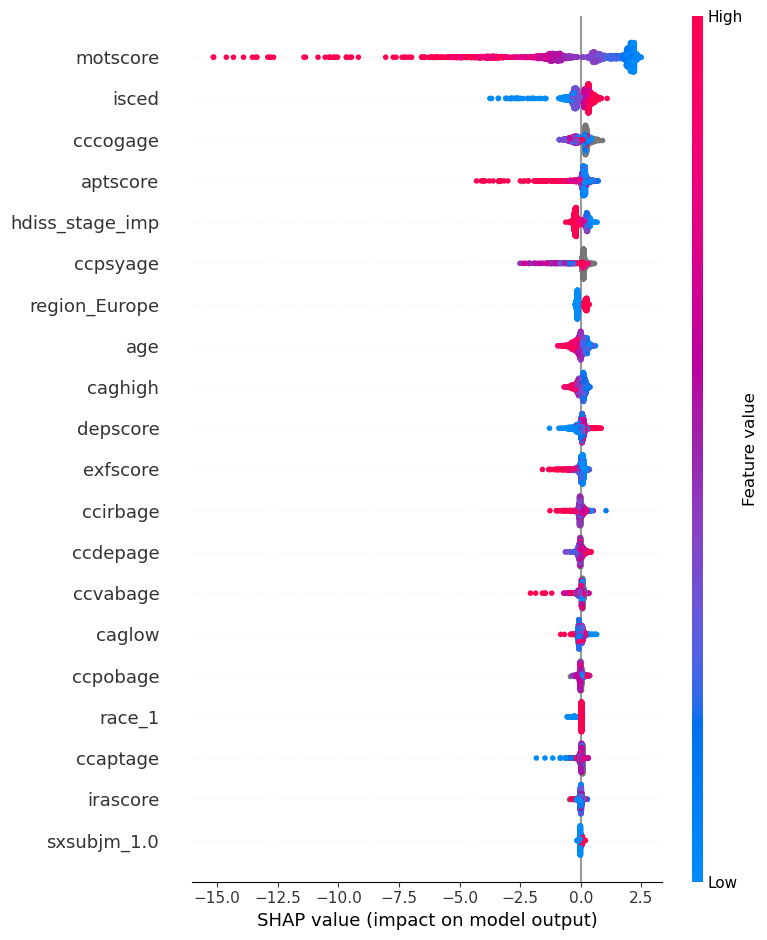

                    feature  mean_abs_shap
5                  motscore       2.001891
3                     isced       0.367285
19                 cccogage       0.261957
9                  aptscore       0.247367
4           hdiss_stage_imp       0.224824
18                 ccpsyage       0.184931
34            region_Europe       0.167303
0                       age       0.163579
11                  caghigh       0.141580
6                  depscore       0.129644
10                 exfscore       0.112669
14                 ccirbage       0.083937
13                 ccdepage       0.081778
15                 ccvabage       0.079669
12                   caglow       0.078656
17                 ccpobage       0.057919
26                   race_1       0.056137
16                 ccaptage       0.054250
7                  irascore       0.039308
20              sxsubjm_1.0       0.036456
1                     sex_f       0.029261
49        19_45411941_T_C_C       0.026889
8          

In [11]:
import numpy as np
import pandas as pd
import xgboost as xgb
import shap
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import mean_squared_error

# =========================
# Preparación de datos
# =========================

df_grouped = df_grouped.dropna(subset=["mmsetotal"])

y = df_grouped["mmsetotal"]
X = df_grouped[[
    'age',
    'sex_f', 'sex_m',
    'isced',
    'hdiss_stage_imp',
    'motscore',
    'depscore','irascore','psyscore','aptscore','exfscore',
    'caghigh','caglow',
    'ccdepage', 'ccirbage', 'ccvabage', 'ccaptage', 'ccpobage', 'ccpsyage', 'cccogage',
    'sxsubjm_1.0','sxsubjm_2.0', 'sxsubjm_3.0', 'sxsubjm_4.0', 'sxsubjm_5.0','sxsubjm_6.0',
    'race_1', 'race_2','race_3', 'race_6', 'race_8', 'race_15', 'race_16',
    'region_Australasia', 'region_Europe', 'region_Latin America','region_Northern America',
    "19_45409113_C_T_T",
    "19_45409167_C_G_C",
    "19_45409283_C_A_A",
    "19_45409579_C_T_T",
    "19_45409988_C_T_T",
    "19_45410002_G_A_A",
    "19_45410273_G_A_A",
    "19_45410444_G_A_A",
    "19_45410548_A_G_G",
    "19_45410911_T_G_G",
    "19_45411110_T_C_C",
    "19_45411722_G_A_A",
    "19_45411941_T_C_C",
    "19_45412040_C_T_T",
    "19_45412079_C_T_T"
]]

# =========================
# Modelo
# =========================

model = xgb.XGBRegressor(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

# =========================
# 🔹 Cross-Validation
# =========================

kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    model,
    X,
    y,
    scoring="neg_root_mean_squared_error",
    cv=kf
)

rmse_scores = -cv_scores

print("Cross-Validation RMSE por fold:", rmse_scores)
print("RMSE medio:", rmse_scores.mean())
print("RMSE std:", rmse_scores.std())

# =========================
# Train/Test final
# =========================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("Test RMSE:", rmse)

# =========================
# 🔹 SHAP Feature Importance
# =========================

explainer = shap.Explainer(model)
shap_values = explainer(X)

# Summary plot (impacto global)
shap.summary_plot(shap_values, X)

# Feature importance media absoluta
shap_importance = np.abs(shap_values.values).mean(axis=0)
importance_df = pd.DataFrame({
    "feature": X.columns,
    "mean_abs_shap": shap_importance
}).sort_values(by="mean_abs_shap", ascending=False)

print(importance_df)

In [20]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
import numpy as np

param_dist = {
    'n_estimators': [100, 200, 500],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7, 10],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'gamma': [0, 0.1, 0.2]
}

xgb_base = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')

random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist,
    n_iter=20, 
    scoring='roc_auc',
    cv=StratifiedKFold(n_splits=5),
    verbose=1,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

#Mejor modelo
best_xgb = random_search.best_estimator_
print(f"Mejores parámetros encontrados: {random_search.best_params_}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Mejores parámetros encontrados: {'subsample': 0.6, 'n_estimators': 500, 'max_depth': 3, 'learning_rate': 0.01, 'gamma': 0.1, 'colsample_bytree': 1.0}


CV Accuracy: 0.8611 +/- 0.0145
CV AUC: 0.9056 +/- 0.0075

--- Reporte de Clasificación ---
              precision    recall  f1-score   support

           0       0.90      0.94      0.92       277
           1       0.75      0.65      0.70        80

    accuracy                           0.87       357
   macro avg       0.83      0.79      0.81       357
weighted avg       0.87      0.87      0.87       357

Test AUC-ROC: 0.9139


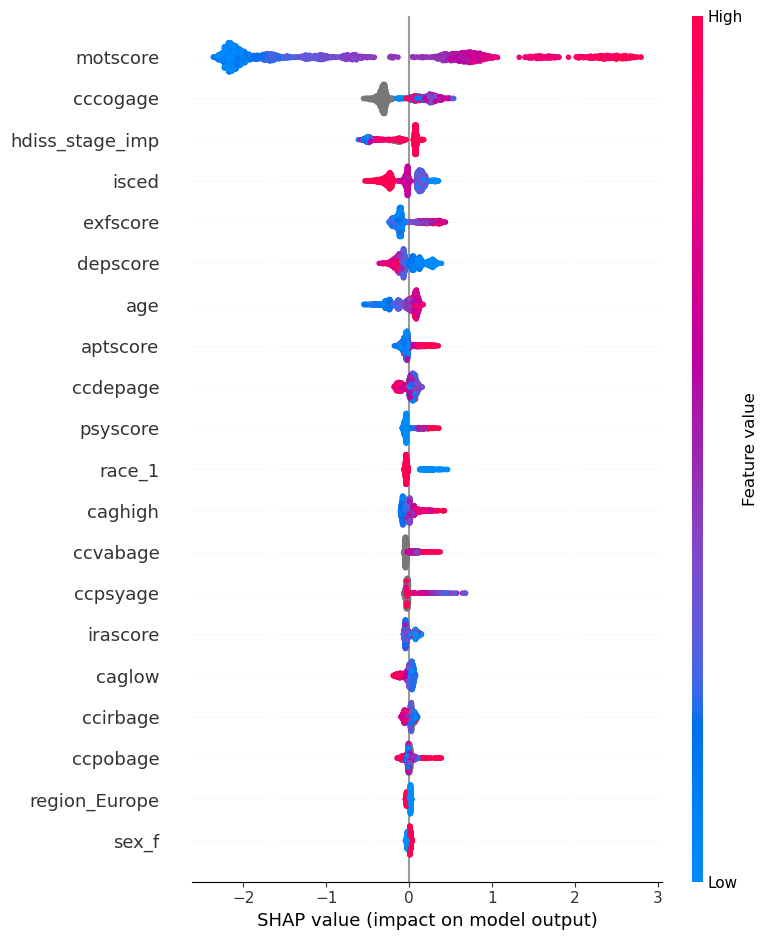


--- Variables por SHAP ---
                    feature  mean_abs_shap
10                 motscore       1.526007
19                 cccogage       0.274803
4           hdiss_stage_imp       0.212539
3                     isced       0.167410
9                  exfscore       0.159068
5                  depscore       0.124795
0                       age       0.117014
8                  aptscore       0.063409
13                 ccdepage       0.062798
7                  psyscore       0.062133
26                   race_1       0.056398
11                  caghigh       0.056092
15                 ccvabage       0.054602
18                 ccpsyage       0.052922
6                  irascore       0.048555
12                   caglow       0.042725
14                 ccirbage       0.038181
17                 ccpobage       0.034470
34            region_Europe       0.018764
1                     sex_f       0.017190
16                 ccaptage       0.017035
20              sxsubjm_1.

In [22]:
import numpy as np
import pandas as pd
import xgboost as xgb
import shap
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, confusion_matrix

df_grouped = df_grouped.dropna(subset=["mmdemencia"])

y = df_grouped["mmdemencia"]
X = df_grouped[[
    'age', 'sex_f', 'sex_m', 'isced', 'hdiss_stage_imp',
    'depscore','irascore','psyscore','aptscore','exfscore', 'motscore',
    'caghigh','caglow',
    'ccdepage', 'ccirbage', 'ccvabage', 'ccaptage', 'ccpobage', 'ccpsyage', 'cccogage',
    'sxsubjm_1.0','sxsubjm_2.0', 'sxsubjm_3.0', 'sxsubjm_4.0', 'sxsubjm_5.0','sxsubjm_6.0',
    'race_1', 'race_2','race_3', 'race_6', 'race_8', 'race_15', 'race_16',
    'region_Australasia', 'region_Europe', 'region_Latin America','region_Northern America',
    "19_45409113_C_T_T", "19_45409167_C_G_C", "19_45409283_C_A_A",
    "19_45409579_C_T_T", "19_45409988_C_T_T", "19_45410002_G_A_A",
    "19_45410273_G_A_A", "19_45410444_G_A_A", "19_45410548_A_G_G",
    "19_45410911_T_G_G", "19_45411110_T_C_C", "19_45411722_G_A_A",
    "19_45411941_T_C_C", "19_45412040_C_T_T", "19_45412079_C_T_T"
]]

model = xgb.XGBClassifier(**random_search.best_params_)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_accuracy = cross_val_score(model, X, y, scoring="accuracy", cv=kf)
cv_auc = cross_val_score(model, X, y, scoring="roc_auc", cv=kf)

print(f"CV Accuracy: {cv_accuracy.mean():.4f} +/- {cv_accuracy.std():.4f}")
print(f"CV AUC: {cv_auc.mean():.4f} +/- {cv_auc.std():.4f}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y # stratify asegura misma proporción de clases
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print("\n--- Reporte de Clasificación ---")
print(classification_report(y_test, y_pred))
print(f"Test AUC-ROC: {roc_auc_score(y_test, y_proba):.4f}")

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X)

shap.summary_plot(shap_values, X)

importance_df = pd.DataFrame({
    "feature": X.columns,
    "mean_abs_shap": np.abs(shap_values).mean(axis=0)
}).sort_values(by="mean_abs_shap", ascending=False)

print("\n--- Variables por SHAP ---")
print(importance_df)

Warning there are missing values in your data !


  0%|          | 0/100 [00:00<?, ?it/s]

5 attributes confirmed important: ['cccogage', 'isced', 'hdiss_stage_imp', 'exfscore', 'motscore']
47 attributes confirmed unimportant: ['race_16', '19_45412079_C_T_T', 'ccpsyage', '19_45410273_G_A_A', 'race_1', '19_45412040_C_T_T', 'region_Northern America', 'region_Europe', '19_45411941_T_C_C', 'psyscore', 'sxsubjm_6.0', 'race_6', 'irascore', 'sxsubjm_1.0', '19_45409283_C_A_A', '19_45411110_T_C_C', 'sxsubjm_4.0', 'race_3', '19_45410911_T_G_G', '19_45409988_C_T_T', 'race_8', '19_45410444_G_A_A', '19_45409113_C_T_T', '19_45409167_C_G_C', '19_45410002_G_A_A', '19_45410548_A_G_G', 'ccirbage', 'ccaptage', 'sxsubjm_3.0', 'race_15', 'region_Australasia', 'caghigh', 'sex_m', 'region_Latin America', 'sex_f', '19_45411722_G_A_A', 'age', 'aptscore', 'ccvabage', 'sxsubjm_2.0', 'caglow', 'ccpobage', 'depscore', 'sxsubjm_5.0', '19_45409579_C_T_T', 'race_2', 'ccdepage']
0 tentative attributes remains: []


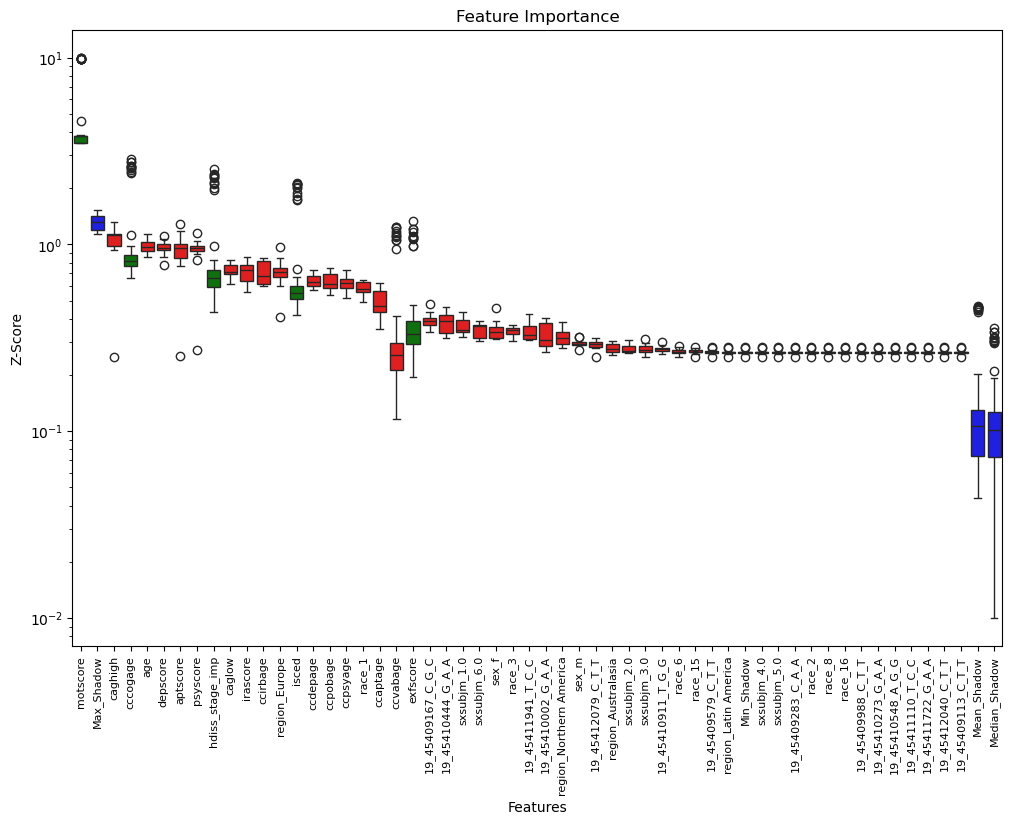

In [13]:
import scipy.stats
scipy.stats.binom_test = scipy.stats.binomtest

if not hasattr(np, 'NaN'):
    np.NaN = np.nan
if not hasattr(np, 'float'):
    np.float = float

def binom_test_integer_safe(k, n, p, alternative):
    return scipy.stats.binomtest(int(k), int(n), p=p, alternative=alternative).pvalue


import BorutaShap

BorutaShap.binom_test = binom_test_integer_safe

from xgboost import XGBClassifier 
import pandas as pd

Feature_Selector = BorutaShap.BorutaShap(model=model, importance_measure='shap', classification=True)

Feature_Selector.fit(X=X_train, y=y_train, n_trials=100, sample=False)

Feature_Selector.plot(which_features='all')

In [26]:
from sklearn.model_selection import KFold

list_selected_features = []

kf = KFold(n_splits=5, shuffle=True, random_state=42)

for i, (train_index, val_index) in enumerate(kf.split(X_train)):
    print(f"--- Ejecutando BorutaShap en Fold {i+1} ---")
    
    X_fold = X_train.iloc[train_index]
    y_fold = y_train.iloc[train_index]
    
    Feature_Selector = BorutaShap.BorutaShap(
        model=best_xgb, 
        importance_measure='shap', 
        classification=True
    )
    
    Feature_Selector.fit(X=X_fold, y=y_fold, n_trials=50, sample=False, verbose=False)
    
    list_selected_features.append(Feature_Selector.accepted)

from collections import Counter
all_features = [item for sublist in list_selected_features for item in sublist]
feature_consistency = Counter(all_features)

print("\nConsistencia de variables (en cuántos folds fueron aceptadas):")
for feat, count in feature_consistency.items():
    print(f"{feat}: {count}/5")

--- Ejecutando BorutaShap en Fold 1 ---
Warning there are missing values in your data !


  0%|          | 0/50 [00:00<?, ?it/s]

--- Ejecutando BorutaShap en Fold 2 ---
Warning there are missing values in your data !


  0%|          | 0/50 [00:00<?, ?it/s]

--- Ejecutando BorutaShap en Fold 3 ---
Warning there are missing values in your data !


...

--- Ejecutando BorutaShap en Fold 4 ---
Warning there are missing values in your data !


  0%|          | 0/50 [00:00<?, ?it/s]

--- Ejecutando BorutaShap en Fold 5 ---
Warning there are missing values in your data !


  0%|          | 0/50 [00:00<?, ?it/s]


Consistencia de variables (en cuántos folds fueron aceptadas):
age: 1/5
cccogage: 4/5
isced: 4/5
hdiss_stage_imp: 4/5
exfscore: 3/5
motscore: 5/5
ccvabage: 1/5
